### マチレポによる交通量分析

In [43]:
import pandas as pd
import os
import sys
import numpy as np
import japanize_matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'IPAexGothic'
import seaborn as sns
import warnings
import json

warnings.filterwarnings("ignore")

traffic_data_path = "data/20250729_195545_2024年_6月_志方"
distance_data_path = r"../data/20250729_195545_2024年_6月_志方/月次_【市区町村別】来訪者居住地マップ.csv"
distance_data = pd.read_csv(distance_data_path, encoding='shift_jis')
# print(distance_data.head())
# 不要な列を削除
removed_columns = ["area_id", "area_name", "area_lat", "area_lon", "ranking"]
distance_data = distance_data.drop(columns=removed_columns, errors='ignore')


In [45]:
# 1.データの加工：直線距離⇒道路距離，道路距離が10km以上のデータを抽出
import requests
import pandas as pd
import time

def get_gsi_coordinates(address):
    """
    国土地理院のAPIを使い、地名から座標（経度, 緯度）を取得する関数
    """
    # 国土地理院のジオコーディングAPIのエンドポイント
    url = f"https://msearch.gsi.go.jp/address-search/AddressSearch?q={address}"
    
    try:
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
            # 結果が見つかった場合
            if data and len(data) > 0:
                # 国土地理院も [経度, 緯度] の順番で返す
                coordinates = data[0]["geometry"]["coordinates"]
                return coordinates
            else:
                return None # 見つからない場合はNone
        else:
            return None
            
    except Exception as e:
        print(f"リクエスト中にエラーが発生しました: {e}")
        return None

# 
locations = distance_data['fromaddress'].unique().tolist()  # ユニークな地名を取得
results = []

for loc in locations:
    coords = get_gsi_coordinates(loc)
    
    if coords:
        longitude, latitude = coords
        print(f"「{loc}」の座標 -> 緯度: {latitude:.6f}, 経度: {longitude:.6f}")
        results.append({'地名': loc, '緯度': latitude, '経度': longitude})
    else:
        print(f"「{loc}」の座標は見つかりませんでした。")
        results.append({'地名': loc, '緯度': '取得不可', '経度': '取得不可'})
    
    time.sleep(0.5) # サーバーへの負荷を考慮
results_df = pd.DataFrame(results)
print("\n--- 最終結果 ---")
print(results_df)
results_df.to_csv("202406_adress_latlon.csv", index=False, encoding='utf-8-sig')

「兵庫県加古川市」の座標 -> 緯度: 34.756924, 経度: 134.841293
「兵庫県高砂市」の座標 -> 緯度: 34.766361, 経度: 134.790573
「兵庫県姫路市」の座標 -> 緯度: 34.815277, 経度: 134.685562
「兵庫県明石市」の座標 -> 緯度: 34.643131, 経度: 134.997604
「兵庫県神戸市西区」の座標 -> 緯度: 34.720913, 経度: 135.019333
「兵庫県加西市」の座標 -> 緯度: 34.927864, 経度: 134.841797
「兵庫県たつの市」の座標 -> 緯度: 34.857857, 経度: 134.545334
「兵庫県神戸市垂水区」の座標 -> 緯度: 34.630554, 経度: 135.056946
「兵庫県加古郡稲美町」の座標 -> 緯度: 34.748390, 経度: 134.912949
「兵庫県加古郡播磨町」の座標 -> 緯度: 34.715279, 経度: 134.868057
「兵庫県揖保郡太子町」の座標 -> 緯度: 34.833244, 経度: 134.572311
「兵庫県三木市」の座標 -> 緯度: 34.796852, 経度: 134.990219
「兵庫県小野市」の座標 -> 緯度: 34.857880, 経度: 134.939880
「兵庫県神戸市須磨区」の座標 -> 緯度: 34.658642, 経度: 135.133667
「兵庫県赤穂市」の座標 -> 緯度: 34.755001, 経度: 134.390274
「兵庫県西宮市」の座標 -> 緯度: 34.737740, 経度: 135.341843
「兵庫県神戸市北区」の座標 -> 緯度: 34.724174, 経度: 135.146210
「兵庫県尼崎市」の座標 -> 緯度: 34.733334, 経度: 135.406387
「兵庫県神戸市兵庫区」の座標 -> 緯度: 34.680237, 経度: 135.165817
「兵庫県神戸市東灘区」の座標 -> 緯度: 34.720211, 経度: 135.265671
「兵庫県神戸市中央区」の座標 -> 緯度: 34.689701, 経度: 135.194855
「兵庫県宍粟市」の座標 -> 緯度: 35.004

In [46]:
def get_gsi_coordinates(address):
    """
    国土地理院のAPIを使い、地名から座標（経度, 緯度）を取得する関数
    （目的地の座標取得にのみ使用）
    """
    url = f"https://msearch.gsi.go.jp/address-search/AddressSearch?q={address}"
    try:
        response = requests.get(url)
        if response.status_code == 200 and response.json():
            return response.json()[0]["geometry"]["coordinates"]
        return None
    except Exception as e:
        print(f"  [!] 国土地理院APIエラー ({address}): {e}")
        return None

def get_ors_route(api_key, start_coords, end_coords):
    """
    OpenRouteService APIを使い、2点間の経路情報（距離・時間）を取得する関数
    """
    headers = {
        'Authorization': api_key,
        'Content-Type': 'application/json'
    }
    # ORSは [経度, 緯度] の順で座標を指定
    body = {"coordinates": [start_coords, end_coords]}
    url = "https://api.openrouteservice.org/v2/directions/driving-car"
    
    try:
        response = requests.post(url, json=body, headers=headers)
        if response.status_code == 200:
            route = response.json()['routes'][0]
            distance_km = route['summary']['distance'] / 1000
            duration_min = route['summary']['duration'] / 60
            return {'distance_km': distance_km, 'duration_min': duration_min}
        else:
            print(f"  [!] ORS APIエラー (Status: {response.status_code})")
            return None
    except Exception as e:
        print(f"  [!] ORS APIエラー: {e}")
        return None

# --- メイン処理 ---
# 1. 設定
ORS_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6ImIxMDNmNmMxMDdkNDRmZTlhMDlmNDc3NzAxMjY1ZDZlIiwiaCI6Im11cm11cjY0In0="
destination_name = "兵庫県加古川市"

# 2. 既存の座標データ（ダミー）
# 実際には、この部分をご自身が作成したデータフレームに置き換えてください
initial_data = results
df_origins = pd.DataFrame(initial_data)
print("--- 入力データ（座標リスト） ---")
print(df_origins)

# 3. 処理の実行
if ORS_API_KEY == "YOUR_ORS_API_KEY_HERE":
    print("\n警告：APIキーが設定されていません。OpenRouteServiceでキーを取得し、置き換えてください。")
else:
    routing_results = []
    
    # 目的地の座標を一度だけ取得
    print(f"\n目的地の座標を取得中: {destination_name}...")
    destination_coords = get_gsi_coordinates(destination_name)

    if destination_coords:
        print("-> 成功\n")
        
        # ★★★ 修正ポイント ★★★
        # データフレームの各行に対してループ処理
        for index, row in df_origins.iterrows():
            origin_name = row['地名']
            start_coords = [row['経度'], row['緯度']] # [経度, 緯度]のリストを作成
            
            print(f"経路を計算中: {origin_name}...")
            
            # OpenRouteService APIで経路情報を取得
            route_info = get_ors_route(ORS_API_KEY, start_coords, destination_coords)
            
            if route_info:
                routing_results.append({
                    '出発地': origin_name,
                    '道路距離(km)': round(route_info['distance_km'], 2),
                    '所要時間(分)': round(route_info['duration_min'])
                })
                print("  -> 成功")
            else:
                routing_results.append({'出発地': origin_name, '道路距離(km)': '経路計算失敗', '所要時間(分)': '経路計算失敗'})
            
            time.sleep(1) # APIの利用制限を考慮

        # 4. 最終結果をデータフレームで表示
        df_final_results = pd.DataFrame(routing_results)
        print("\n--- 最終結果 ---")
        print(df_final_results)
    else:
        print(f"目的地の座標が取得できなかったため、処理を中断しました。")

--- 入力データ（座標リスト） ---
              地名         緯度          経度
0        兵庫県加古川市  34.756924  134.841293
1         兵庫県高砂市  34.766361  134.790573
2         兵庫県姫路市  34.815277  134.685562
3         兵庫県明石市  34.643131  134.997604
4       兵庫県神戸市西区  34.720913  135.019333
..           ...        ...         ...
222   鹿児島県曽於郡大崎町  31.429167  131.005829
223      福島県いわき市  37.050453  140.887726
224  福岡県北九州市八幡西区  33.866409  130.764297
225       京都府南丹市  35.107288  135.470703
226       香川県丸亀市  34.289886  133.798706

[227 rows x 3 columns]

目的地の座標を取得中: 兵庫県加古川市...
-> 成功

経路を計算中: 兵庫県加古川市...
  [!] ORS APIエラー: 'distance'
経路を計算中: 兵庫県高砂市...
  -> 成功
経路を計算中: 兵庫県姫路市...
  -> 成功
経路を計算中: 兵庫県明石市...
  -> 成功
経路を計算中: 兵庫県神戸市西区...
  -> 成功
経路を計算中: 兵庫県加西市...
  -> 成功
経路を計算中: 兵庫県たつの市...
  -> 成功
経路を計算中: 兵庫県神戸市垂水区...
  -> 成功
経路を計算中: 兵庫県加古郡稲美町...
  -> 成功
経路を計算中: 兵庫県加古郡播磨町...
  -> 成功
経路を計算中: 兵庫県揖保郡太子町...
  -> 成功
経路を計算中: 兵庫県三木市...
  -> 成功
経路を計算中: 兵庫県小野市...
  -> 成功
経路を計算中: 兵庫県神戸市須磨区...
  -> 成功
経路を計算中: 兵庫県赤穂市...
  -> 成功
経路を計算中: 兵庫県西宮市

In [11]:
# 休日のデータを読み込む
distance_weekend = distance_data[distance_data['dayflag'] == '休日']
# 距離ごとの訪問者数を集計。
# 境界条件のSOCを5％刻みの入力データとして扱いたい。
DENPI = 7 # 電費の単位km/kwh
BATTERY_CAPACITY = 60 # バッテリー容量kWh
soc_per_kwh = 100 / BATTERY_CAPACITY # 1kWhあたりのSOCの割合
bin_distance = DENPI / soc_per_kwh * 5 # 距離の刻みを5％ごとに
bins = np.arange(bin_distance, 300, bin_distance)  # 0から100までの距離を5％刻みで設定
labels = [f"{(i+1)*5}%" for i in range(len(bins)-1)]  # ラベルを5％刻みで設定
# binsの最小値・最大値をデータの最小・最大に合わせて拡張
min_distance = distance_weekend['distance'].min()
max_distance = distance_weekend['distance'].max()

# binsの先頭と末尾を調整
bins[0] = min(bins[0], min_distance)
bins[-1] = max(bins[-1], max_distance)

distance_weekend['consumed_soc'] = pd.cut(distance_weekend['distance'], bins=bins, labels=labels, include_lowest=True)
print(bins)
print(labels)

distance_weekend.head()

[ 10.349  42.     63.     84.    105.    126.    147.    168.    189.
 210.    231.    252.    273.    722.374]
['5%', '10%', '15%', '20%', '25%', '30%', '35%', '40%', '45%', '50%', '55%', '60%', '65%']


,period,dayflag,fromaddress,distance,population,consumed_soc
2,202406,休日,兵庫県姫路市,17.834,21671,5%
3,202406,休日,兵庫県明石市,16.950,6652,5%
4,202406,休日,兵庫県神戸市西区,19.710,2945,5%
5,202406,休日,兵庫県加西市,14.160,2192,5%
6,202406,休日,兵庫県たつの市,29.470,2123,5%


In [12]:
# 距離カテゴリごとにpopulationを合計
distance_pop_weekend = distance_weekend.groupby('consumed_soc')['population'].sum().reset_index()

# 全体の合計
total_pop_weekend = distance_pop_weekend['population'].sum()

# 割合を計算
distance_pop_weekend['ratio'] = distance_pop_weekend['population'] / total_pop_weekend * 100  # 平日と休日の割合を比較するために100倍


In [13]:
# 平日でも同様の操作を行う。
distance_weekday = distance_data[distance_data['dayflag'] == '平日']
# 距離ごとの訪問者数を集計。
# binsの最小値・最大値をデータの最小・最大に合わせて拡張
min_distance = distance_weekday['distance'].min()
max_distance = distance_weekday['distance'].max()

# binsの先頭と末尾を調整
bins[0] = min(bins[0], min_distance)
bins[-1] = max(bins[-1], max_distance)

distance_weekday['consumed_soc'] = pd.cut(distance_weekday['distance'], bins=bins, labels=labels, include_lowest=True)
print(bins)
print(labels)

distance_weekday.head()

[ 10.349  42.     63.     84.    105.    126.    147.    168.    189.
 210.    231.    252.    273.    722.374]
['5%', '10%', '15%', '20%', '25%', '30%', '35%', '40%', '45%', '50%', '55%', '60%', '65%']


,period,dayflag,fromaddress,distance,population,consumed_soc
202,202406,平日,兵庫県姫路市,17.834,21489,5%
203,202406,平日,兵庫県明石市,16.950,5913,5%
204,202406,平日,兵庫県神戸市西区,19.710,2886,5%
205,202406,平日,兵庫県加西市,14.160,1918,5%
206,202406,平日,兵庫県たつの市,29.470,1758,5%


   consumed_soc  population      ratio
0            5%       48703  74.042598
1           10%        4931   7.496541
2           15%        3920   5.959530
3           20%        1887   2.868784
4           25%         347   0.527540
5           30%         339   0.515378
6           35%         148   0.225003
7           40%         122   0.185475
8           45%         142   0.215881
9           50%         237   0.360308
10          55%          54   0.082096
11          60%          27   0.041048
12          65%         230   0.349666


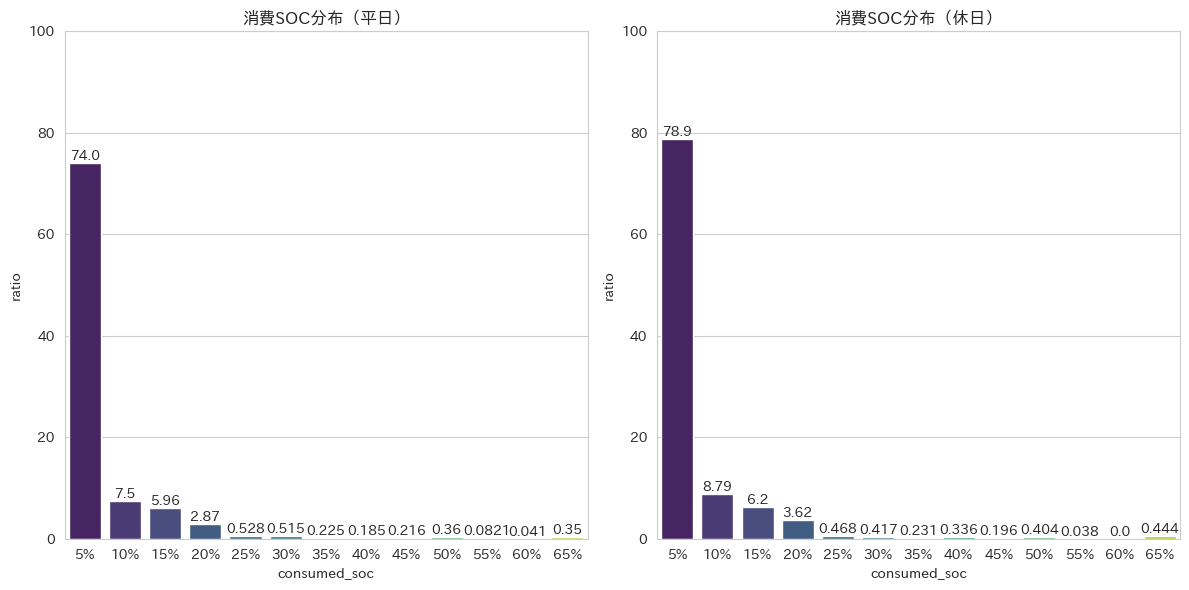

In [14]:
# 距離カテゴリごとにpopulationを合計
distance_pop_weekday = distance_weekday.groupby('consumed_soc')['population'].sum().reset_index()

# 全体の合計
total_pop_weekday = distance_pop_weekday['population'].sum()

# 割合を計算
distance_pop_weekday['ratio'] = distance_pop_weekday['population'] / total_pop_weekend * 100  # 平日と休日の割合を比較するために100倍

# 結果表示
print(distance_pop_weekday)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
ax_weekday = sns.barplot(x='consumed_soc', y='ratio', data=distance_pop_weekday, palette='viridis')
plt.title('消費SOC分布（平日）')
plt.ylim(0, 100)
# 棒グラフ上に割合を表示
for p in ax_weekday.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax_weekday.text(
            p.get_x() + p.get_width() / 2,  # x座標（バーの中央）
            height,                         # y座標（バーの上）
            f'{height:.3}',                # パーセント表示
            ha='center', va='bottom', fontsize=10
        )
plt.tight_layout()

plt.subplot(1, 2, 2)
ax_weekend = sns.barplot(x='consumed_soc', y='ratio', data=distance_pop_weekend, palette='viridis')
plt.title('消費SOC分布（休日）')
plt.ylim(0, 100)
# 棒グラフ上に割合を表示
for p in ax_weekend.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax_weekend.text(
            p.get_x() + p.get_width() / 2,  # x座標（バーの中央）
            height,                         # y座標（バーの上）
            f'{height:.3}',                # パーセント表示
            ha='center', va='bottom', fontsize=10
        )
plt.tight_layout()
plt.show()


- これは対象エリアに来訪した全体のユーザーの走行距離から，消費SOCを逆算した値である。あくまで参考値にとどめるべきであり，これをもとに道路の種類に応じて消費SOC分布を変えるべき。

In [15]:
# 次に時間帯別の訪問者数を集計する。
visitors_data_path = r"../data/20250729_133457_2024年_月次_志方/月次_時間帯別来訪者数.csv"
visitors_data = pd.read_csv(visitors_data_path, encoding='shift_jis')
# 不要な列を削除
removed_columns = ["area_id", "area_name"]
visitors_data = visitors_data.drop(columns=removed_columns, errors='ignore')
visitors_data.head()

,period,dayflag,hour,population,rate
0,202401,休日,0,48883,0.038
1,202401,休日,1,48727,0.038
2,202401,休日,2,48609,0.037
3,202401,休日,3,48495,0.037
4,202401,休日,4,48710,0.038


In [16]:
# 休日のデータを抽出
visitors_weekend = visitors_data[visitors_data['dayflag'] == '休日']
# 平日のデータを抽出
visitors_weekday = visitors_data[visitors_data['dayflag'] == '平日']
# 月別のデータを抽出
visitors_monthly = visitors_weekend.groupby('period')
visitors_monthly.head()

,period,dayflag,hour,population,rate
0,202401,休日,0,48883,0.038
1,202401,休日,1,48727,0.038
2,202401,休日,2,48609,0.037
3,202401,休日,3,48495,0.037
4,202401,休日,4,48710,0.038
24,202402,休日,0,48930,0.037
25,202402,休日,1,48568,0.037
26,202402,休日,2,48442,0.037
27,202402,休日,3,48284,0.037
28,202402,休日,4,48504,0.037


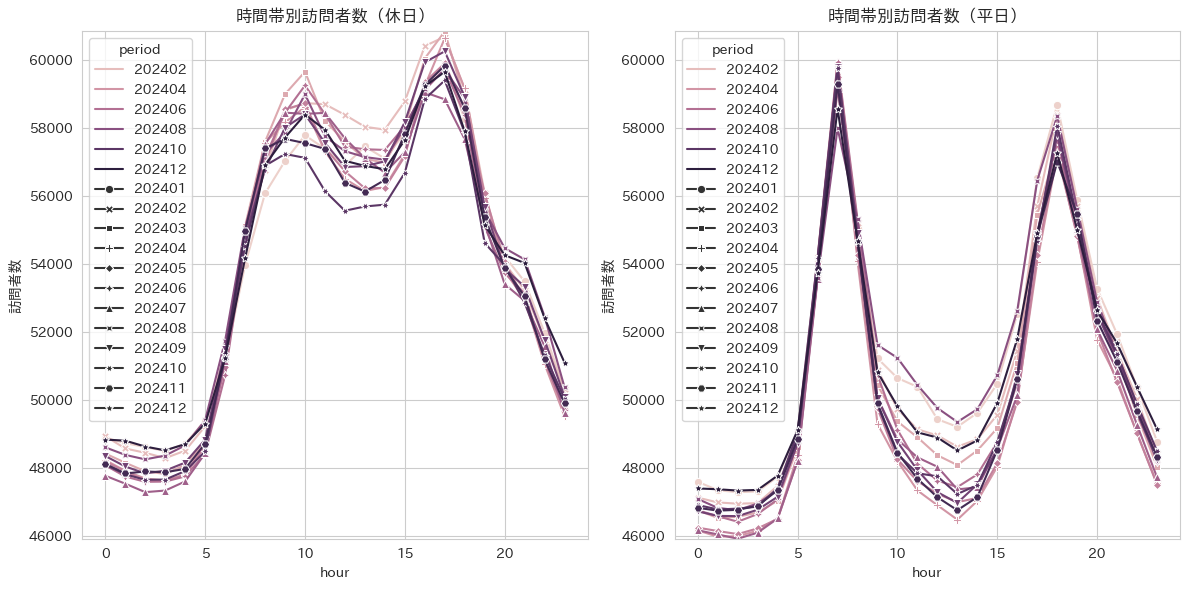

In [17]:
import japanize_matplotlib
plt.figure(figsize=(12, 6))
# 時間帯別の訪問者数をプロット
plt.subplot(1, 2, 1)
ax1 = sns.lineplot(
    data=visitors_weekend,
    x='hour',
    y='population',
    hue='period',  # 月（period）ごとに色を変える
    style='period', # 月（period）ごとに線のスタイルも変える
    markers=True,  # データ点にマーカーをプロットする
    dashes=False
)
plt.title('時間帯別訪問者数（休日）')
plt.ylabel('訪問者数')
plt.grid(True)

plt.subplot(1, 2, 2)
ax2 = sns.lineplot(
    data=visitors_weekday,
    x='hour',
    y='population',
    hue='period',  # 月（period）ごとに色を変える
    style='period', # 月（period）ごとに線のスタイルも変える
    markers=True,  # データ点にマーカーをプロットする
    dashes=False
)
plt.title('時間帯別訪問者数（平日）')
plt.ylabel('訪問者数')
plt.grid(True)
# y軸を一致させる
max_y = max(visitors_weekend['population'].max(), visitors_weekday['population'].max())
min_y = min(visitors_weekend['population'].min(), visitors_weekday['population'].min())
ax1.set_ylim(min_y, max_y)
ax2.set_ylim(min_y, max_y)
plt.tight_layout()
plt.show()

--- 「季節」列を追加したデータ（一部）---
   period dayflag  hour  population   rate      season
0  202401      休日     0       48883  0.038  冬 (Winter)
1  202401      休日     1       48727  0.038  冬 (Winter)
2  202401      休日     2       48609  0.037  冬 (Winter)
3  202401      休日     3       48495  0.037  冬 (Winter)
4  202401      休日     4       48710  0.038  冬 (Winter)


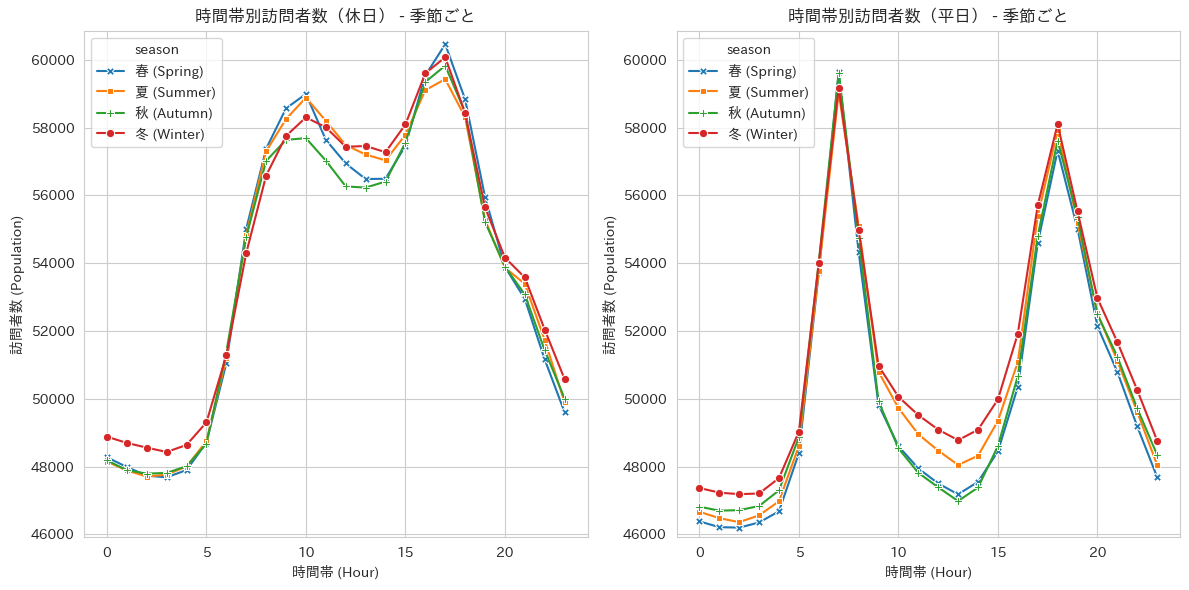

In [21]:
# 見にくいので，春夏秋冬に分けて季節変動性を確認する。
# 2. 「季節」列の追加
# 月の数値を取り出し、季節を割り当てる
month_to_season = {
    1: '冬 (Winter)', 2: '冬 (Winter)', 3: '春 (Spring)',
    4: '春 (Spring)', 5: '春 (Spring)', 6: '夏 (Summer)',
    7: '夏 (Summer)', 8: '夏 (Summer)', 9: '秋 (Autumn)',
    10: '秋 (Autumn)', 11: '秋 (Autumn)', 12: '冬 (Winter)'
}
# period(yyyymm)から月(mm)を抽出し、季節にマッピング
visitors_weekend['season'] = visitors_weekend['period'].astype(str).str[-2:].astype(int).map(month_to_season)
visitors_weekday['season'] = visitors_weekday['period'].astype(str).str[-2:].astype(int).map(month_to_season)
# 「季節」列を確認
print("--- 「季節」列を追加したデータ（一部）---")
print(visitors_weekend.head())

# 3. グラフの描画設定
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'IPAexGothic'  # フォント設定

# 4. Seabornを使って季節ごとに集約したグラフを描画
plt.subplot(1, 2, 1)
ax1 = sns.lineplot(
    data=visitors_weekend,
    x='hour',
    y='population',
    hue='season',  # ★★★ 変更点：'period'から'season'に変更
    hue_order=['春 (Spring)', '夏 (Summer)', '秋 (Autumn)', '冬 (Winter)'], # 凡例の表示順を指定
    style='season', # スタイルも季節ごとに変える
    markers=True,
    dashes=False,
    errorbar=None  # 平均値の線のみ表示（信頼区間を非表示）
)
plt.title('時間帯別訪問者数（休日） - 季節ごと')
plt.xlabel('時間帯 (Hour)')
plt.ylabel('訪問者数 (Population)')

plt.subplot(1, 2, 2)
ax2 = sns.lineplot(
    data=visitors_weekday,
    x='hour',
    y='population',
    hue='season',  # ★★★ 変更点：'period'から'season'に変更
    hue_order=['春 (Spring)', '夏 (Summer)', '秋 (Autumn)', '冬 (Winter)'], # 凡例の表示順を指定
    style='season', # スタイルも季節ごとに変える
    markers=True,
    dashes=False,
    errorbar=None  # 平均値の線のみ表示（信頼区間を非表示）
)
plt.title('時間帯別訪問者数（平日） - 季節ごと')
plt.xlabel('時間帯 (Hour)')
plt.ylabel('訪問者数 (Population)')
min_y = min(visitors_weekend['population'].min(), visitors_weekday['population'].min())
max_y = max(visitors_weekend['population'].max(), visitors_weekday['population'].max())
ax1.set_ylim(min_y, max_y)
ax2.set_ylim(min_y, max_y)
plt.tight_layout()
plt.show()


- 来訪者データから，対象エリア内のユーザーの居住地をもとに走行距離を算出することができた。一方で，経路充電需要を求めるためにはエリア内の動いていないかつ車両以外のデータは排除したい。志方から10km以内の距離の市区町村（確認した限りでは，加古川市と高砂市）を除外した走行距離分布を作成している。

#### 最終的には道路別のSOC分布を作成したい。一般国道のような長距離移動が多い道路もあれば，生活道路のような地域内で完結する中小距離移動が主な道路もある。これを同一のSOC分布に基づいて境界SOCを決めてしまうのは一般国道などの走行距離を過小評価する恐れがある。そこで，出発地ごとにルーティングを行って出発地ごとの通る道路を求め，それをもとに境界SOCを設定する。

##### 1.出発地ごとのlatlonを算出→2.出発地to目的地の最短経路をORSで取得→3.道路に沿った距離を算出＆トリップごとの通る道路を求める。

In [ ]:
locations = distance_weekday['fromaddress'].unique().tolist()  # ユニークな地名を取得
results = []

for loc in locations:
    coords = get_gsi_coordinates(loc)
    
    if coords:
        longitude, latitude = coords
        print(f"「{loc}」の座標 -> 緯度: {latitude:.6f}, 経度: {longitude:.6f}")
        results.append({'地名': loc, '緯度': latitude, '経度': longitude})
    else:
        print(f"「{loc}」の座標は見つかりませんでした。")
        results.append({'地名': loc, '緯度': '取得不可', '経度': '取得不可'})
    
    time.sleep(0.5) # サーバーへの負荷を考慮
results_df = pd.DataFrame(results)
print("\n--- 最終結果 ---")
print(results_df)
results_df.to_csv("202406_adress_latlon.csv", index=False, encoding='utf-8-sig')

「兵庫県姫路市」の座標 -> 緯度: 34.815277, 経度: 134.685562
「兵庫県明石市」の座標 -> 緯度: 34.643131, 経度: 134.997604
「兵庫県神戸市西区」の座標 -> 緯度: 34.720913, 経度: 135.019333
「兵庫県加西市」の座標 -> 緯度: 34.927864, 経度: 134.841797
「兵庫県たつの市」の座標 -> 緯度: 34.857857, 経度: 134.545334
「兵庫県神戸市垂水区」の座標 -> 緯度: 34.630554, 経度: 135.056946
「兵庫県加古郡播磨町」の座標 -> 緯度: 34.715279, 経度: 134.868057
「兵庫県加古郡稲美町」の座標 -> 緯度: 34.748390, 経度: 134.912949
「兵庫県揖保郡太子町」の座標 -> 緯度: 34.833244, 経度: 134.572311
「兵庫県神戸市須磨区」の座標 -> 緯度: 34.658642, 経度: 135.133667
「兵庫県小野市」の座標 -> 緯度: 34.857880, 経度: 134.939880
「兵庫県三木市」の座標 -> 緯度: 34.796852, 経度: 134.990219
「兵庫県西宮市」の座標 -> 緯度: 34.737740, 経度: 135.341843
「兵庫県神戸市北区」の座標 -> 緯度: 34.724174, 経度: 135.146210
「兵庫県赤穂市」の座標 -> 緯度: 34.755001, 経度: 134.390274
「兵庫県神戸市中央区」の座標 -> 緯度: 34.689701, 経度: 135.194855
「兵庫県神戸市兵庫区」の座標 -> 緯度: 34.680237, 経度: 135.165817
「兵庫県相生市」の座標 -> 緯度: 34.803612, 経度: 134.468063
「兵庫県尼崎市」の座標 -> 緯度: 34.733334, 経度: 135.406387
「兵庫県神戸市東灘区」の座標 -> 緯度: 34.720211, 経度: 135.265671
「兵庫県神戸市灘区」の座標 -> 緯度: 34.712418, 経度: 135.239456
「兵庫県神戸市長田区」の座標 -> 緯度: 34

In [ ]:
import requests
import pandas as pd
import time

# --- 関数定義 ---

def get_gsi_coordinates(address):
    """
    国土地理院のAPIを使い、地名から座標（経度, 緯度）を取得する関数
    （目的地の座標取得にのみ使用）
    """
    url = f"https://msearch.gsi.go.jp/address-search/AddressSearch?q={address}"
    try:
        response = requests.get(url)
        if response.status_code == 200 and response.json():
            return response.json()[0]["geometry"]["coordinates"]
        return None
    except Exception as e:
        print(f"  [!] 国土地理院APIエラー ({address}): {e}")
        return None

def get_ors_route(api_key, start_coords, end_coords):
    """
    OpenRouteService APIを使い、2点間の経路情報（距離・時間）を取得する関数
    """
    headers = {
        'Authorization': api_key,
        'Content-Type': 'application/json'
    }
    # ORSは [経度, 緯度] の順で座標を指定
    body = {"coordinates": [start_coords, end_coords]}
    url = "https://api.openrouteservice.org/v2/directions/driving-car"
    
    try:
        response = requests.post(url, json=body, headers=headers)
        if response.status_code == 200:
            route = response.json()['routes'][0]
            distance_km = route['summary']['distance'] / 1000
            duration_min = route['summary']['duration'] / 60
            return {'distance_km': distance_km, 'duration_min': duration_min}
        else:
            print(f"  [!] ORS APIエラー (Status: {response.status_code})")
            return None
    except Exception as e:
        print(f"  [!] ORS APIエラー: {e}")
        return None

# --- メイン処理 ---
# 1. 設定
ORS_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6ImIxMDNmNmMxMDdkNDRmZTlhMDlmNDc3NzAxMjY1ZDZlIiwiaCI6Im11cm11cjY0In0="
destination_name = "兵庫県加古川市"

# 2. 既存の座標データ（ダミー）
# 実際には、この部分をご自身が作成したデータフレームに置き換えてください
initial_data = results
df_origins = pd.DataFrame(initial_data)
print("--- 入力データ（座標リスト） ---")
print(df_origins)

# 3. 処理の実行
if ORS_API_KEY == "YOUR_ORS_API_KEY_HERE":
    print("\n警告：APIキーが設定されていません。OpenRouteServiceでキーを取得し、置き換えてください。")
else:
    routing_results = []
    
    # 目的地の座標を一度だけ取得
    print(f"\n目的地の座標を取得中: {destination_name}...")
    destination_coords = get_gsi_coordinates(destination_name)

    if destination_coords:
        print("-> 成功\n")
        
        # ★★★ 修正ポイント ★★★
        # データフレームの各行に対してループ処理
        for index, row in df_origins.iterrows():
            origin_name = row['地名']
            start_coords = [row['経度'], row['緯度']] # [経度, 緯度]のリストを作成
            
            print(f"経路を計算中: {origin_name}...")
            
            # OpenRouteService APIで経路情報を取得
            route_info = get_ors_route(ORS_API_KEY, start_coords, destination_coords)
            
            if route_info:
                routing_results.append({
                    '出発地': origin_name,
                    '道路距離(km)': round(route_info['distance_km'], 2),
                    '所要時間(分)': round(route_info['duration_min'])
                })
                print("  -> 成功")
            else:
                routing_results.append({'出発地': origin_name, '道路距離(km)': '経路計算失敗', '所要時間(分)': '経路計算失敗'})
            
            time.sleep(1.5) # APIの利用制限を考慮

        # 4. 最終結果をデータフレームで表示
        df_final_results = pd.DataFrame(routing_results)
        print("\n--- 最終結果 ---")
        print(df_final_results)
    else:
        print(f"目的地の座標が取得できなかったため、処理を中断しました。")

--- 入力データ（座標リスト） ---
            地名         緯度          経度
0       兵庫県姫路市  34.815277  134.685562
1       兵庫県明石市  34.643131  134.997604
2     兵庫県神戸市西区  34.720913  135.019333
3       兵庫県加西市  34.927864  134.841797
4      兵庫県たつの市  34.857857  134.545334
..         ...        ...         ...
193     京都府南丹市  35.107288  135.470703
194  大阪府三島郡島本町  34.883888  135.662781
195    大阪府四條畷市  34.740002  135.639450
196     香川県丸亀市  34.289886  133.798706
197     愛知県半田市  34.891808  136.938004

[198 rows x 3 columns]

目的地の座標を取得中: 兵庫県加古川市...
-> 成功

経路を計算中: 兵庫県姫路市...
  -> 成功
経路を計算中: 兵庫県明石市...
  -> 成功
経路を計算中: 兵庫県神戸市西区...
  -> 成功
経路を計算中: 兵庫県加西市...
  -> 成功
経路を計算中: 兵庫県たつの市...
  -> 成功
経路を計算中: 兵庫県神戸市垂水区...
  -> 成功
経路を計算中: 兵庫県加古郡播磨町...
  -> 成功
経路を計算中: 兵庫県加古郡稲美町...
  -> 成功
経路を計算中: 兵庫県揖保郡太子町...
  -> 成功
経路を計算中: 兵庫県神戸市須磨区...
  -> 成功
経路を計算中: 兵庫県小野市...
  -> 成功
経路を計算中: 兵庫県三木市...
  -> 成功
経路を計算中: 兵庫県西宮市...
  -> 成功
経路を計算中: 兵庫県神戸市北区...
  -> 成功
経路を計算中: 兵庫県赤穂市...
  -> 成功
経路を計算中: 兵庫県神戸市中央区...
  -> 成功
経路を計算中: 兵庫県神戸市兵庫区...
  -> 成功


In [30]:
df_final_results.head()
df_final_results.to_csv("202406_accurate_routing.csv", index=False, encoding='utf-8-sig')

In [ ]:
destination_coords = get_gsi_coordinates(destination_name)
print(f"目的地「{destination_name}」の座標: {destination_coords}")


目的地「兵庫県加古川市」の座標: [134.841293, 34.756924]


### eMATESの交通量

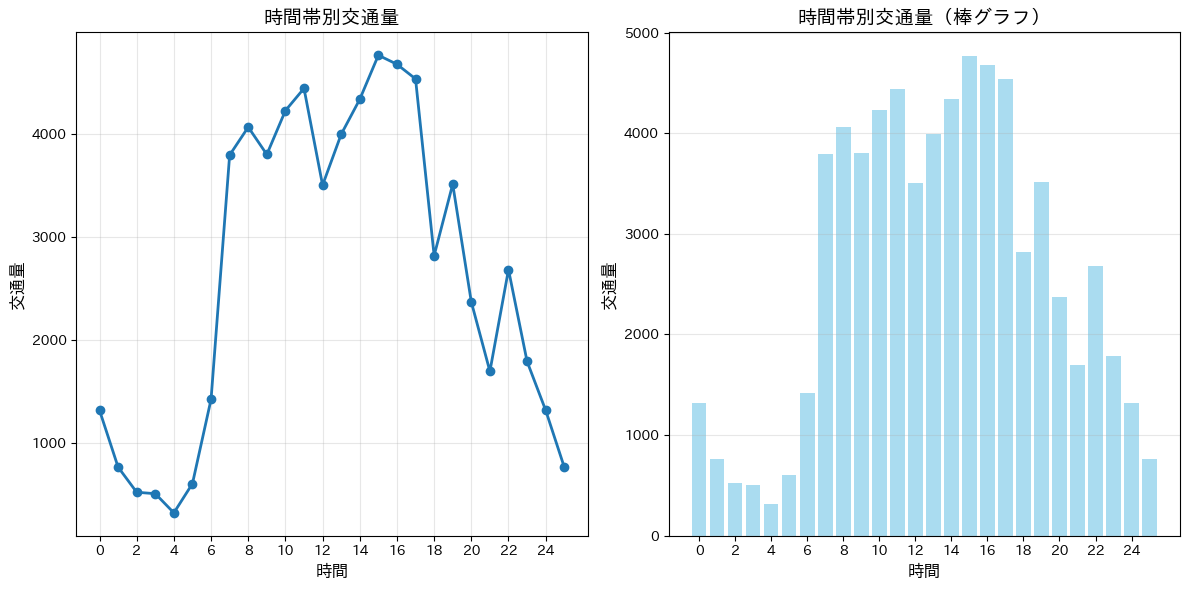

=== 時間別交通量統計 ===
総交通量: 68,532
平均交通量: 2635.85
最大交通量: 4,764 (時刻: 15時)
最小交通量: 320 (時刻: 4時)

ピーク時間帯 TOP3:
15時: 4,764.0
16時: 4,676.0
17時: 4,534.0

データ詳細:
データ点数: 416


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import japanize_matplotlib
plt.rcParams['font.family'] = 'IPAexGothic'

# eMATESの交通量データを読み込み・処理
traffic_path = r"\\wsl.localhost\Ubuntu-22.04\home\tsato-cnlab\Emates\eMATES_2308\network\simple_shikata\generateTable.txt"
with open(traffic_path, 'r', encoding='utf-8') as f:
    traffic_data = f.readlines()

# データを行ごとに分割し、コンマで分割してリスト化
traffic_data = [line.strip().split(',') for line in traffic_data if line.strip()]

# ヘッダー行を取得
header = traffic_data[0]
header = [col.strip('#').strip() for col in header]
# #で始まるコメント行を除去
traffic_data = [line for line in traffic_data if not line[0].startswith('#')]

# DataFrameに変換（ヘッダーを除く）
traffic_df = pd.DataFrame(traffic_data[0:], columns=header)


# 数値列を適切な型に変換
numeric_columns = ['begintime', 'endtime', 'volume']
for col in numeric_columns:
    if col in traffic_df.columns:
        traffic_df[col] = pd.to_numeric(traffic_df[col], errors='coerce')

# 時間を時間単位に変換（ミリ秒から時間へ）
traffic_df['hour'] = traffic_df['begintime'] / (1000 * 3600)

# 時間ごとの交通量を集計
hourly_traffic = traffic_df.groupby('hour')['volume'].sum().reset_index()

# 可視化
plt.figure(figsize=(12, 6))

# 時間別交通量の線グラフ
plt.subplot(1, 2, 1)
plt.plot(hourly_traffic['hour'], hourly_traffic['volume'], marker='o', linewidth=2, markersize=6)
plt.title('時間帯別交通量', fontsize=14)
plt.xlabel('時間', fontsize=12)
plt.ylabel('交通量', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 25, 2))

# 時間別交通量の棒グラフ
plt.subplot(1, 2, 2)
plt.bar(hourly_traffic['hour'], hourly_traffic['volume'], alpha=0.7, color='skyblue')
plt.title('時間帯別交通量（棒グラフ）', fontsize=14)
plt.xlabel('時間', fontsize=12)
plt.ylabel('交通量', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, 25, 2))

plt.tight_layout()
plt.show()

# 統計情報の表示
print("=== 時間別交通量統計 ===")
print(f"総交通量: {hourly_traffic['volume'].sum():,}")
print(f"平均交通量: {hourly_traffic['volume'].mean():.2f}")
print(f"最大交通量: {hourly_traffic['volume'].max():,} (時刻: {hourly_traffic.loc[hourly_traffic['volume'].idxmax(), 'hour']:.0f}時)")
print(f"最小交通量: {hourly_traffic['volume'].min():,} (時刻: {hourly_traffic.loc[hourly_traffic['volume'].idxmin(), 'hour']:.0f}時)")

# ピーク時間帯の特定
peak_hours = hourly_traffic.nlargest(3, 'volume')
print(f"\nピーク時間帯 TOP3:")
for idx, row in peak_hours.iterrows():
    print(f"{row['hour']:.0f}時: {row['volume']:,}")

print(f"\nデータ詳細:")
print(f"データ点数: {len(traffic_df)}")


In [ ]:
# 可視化
